In [82]:
# import packages
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision.transforms import v2
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from torchvision import tv_tensors
import numpy as np
import os
from PIL import Image

In [2]:
# set device
device = torch.device("mps" if torch.mps.is_available() else "cpu")
print(f"Training with devive = {device}.")

Training with devive = mps.


In [12]:
# check how many cores are available for training
num_workers = os.cpu_count()
print(f"You have {num_workers} CPU cores available for training.")

You have 8 CPU cores available for training.


In [ ]:
# use fiftyone to pull just the images of the 2017 MS COCO dataset that have people
import fiftyone.zoo as foz
import fiftyone as fo


train_dataset = foz.load_zoo_dataset(
    "coco-2017",
    split = "train",
    label_types = ["segmentations"],
    classes = ["person"],
    max_samples = 10000
    

)

val_dataset = foz.load_zoo_dataset(
    "coco-2017",
    split = "validation",
    label_types = ["segmentations"],
    classes = ["person"],
    max_samples = 2000

)

Found annotations at '/Users/sethcarden/fiftyone/coco-2017/raw/instances_train2017.json'
Sufficient images already downloaded
Existing download of split 'train' is sufficient
Loading existing dataset 'coco-2017-train-10000'. To reload from disk, either delete the existing dataset or provide a custom `dataset_name` to use
Found annotations at '/Users/sethcarden/fiftyone/coco-2017/raw/instances_val2017.json'


KeyboardInterrupt: 

libc++abi: terminating due to uncaught exception of type std::__1::system_error: Broken pipe
libc++abi: terminating due to uncaught exception of type std::__1::system_error: Broken pipe
Traceback (most recent call last):
  File "/opt/miniconda3/envs/cs224n/lib/python3.12/runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/miniconda3/envs/cs224n/lib/python3.12/runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "/opt/miniconda3/envs/cs224n/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/miniconda3/envs/cs224n/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/miniconda3/envs/cs224n/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/opt/miniconda3/envs/cs224n/lib/python3.12/site-pac

: 

In [ ]:
# export the dataset so it can be handled regularly using PyTorch

train_dataset.export(
    export_dir = "./data/train",
    dataset_type = fo.types.COCODetectionDataset,
    label_field = "ground_truth"
)
val_dataset.export(
    export_dir = "./data/val",
    dataset_type = fo.types.COCODetectionDataset,
    label_field = "ground_truth"
)


 100% |█████████████| 10000/10000 [2.9m elapsed, 0s remaining, 50.4 samples/s]       
 100% |███████████████| 2000/2000 [36.5s elapsed, 0s remaining, 65.7 samples/s]      


In [6]:
# define datasets
from utilities.dataset import MSCOCO

train_transform = v2.Compose([
    v2.RandomResizedCrop(size = (512, 512), antialias = True),
    v2.RandomHorizontalFlip(p=0.5),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale = True),
    v2.Normalize(mean = [0.485, 0.456, 0.406], std =[0.229, 0.224, 0.225])
])

val_transform = v2.Compose([
    v2.Resize(size = (512, 512), antialias = True),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale = True),
    v2.Normalize(mean = [0.485, 0.456, 0.406], std =[0.229, 0.224, 0.225])
])

train_dataset = MSCOCO(image_directory = "./data/train/data", annotations_filepath = "./data/train/labels.json", transform = train_transform)
val_dataset = MSCOCO(image_directory = "./data/val/data", annotations_filepath = "./data/val/labels.json", transform = val_transform)

# get datalooaders
train_loader = DataLoader(train_dataset, batch_size = 4, shuffle = True, num_workers = 2, persistent_workers = True)
val_loader = DataLoader(val_dataset, batch_size = 4, shuffle = False)

loading annotations into memory...
Done (t=0.38s)
creating index...
index created!
loading annotations into memory...
Done (t=0.07s)
creating index...
index created!


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DiceBCELoss(nn.Module):
    def __init__(self, device = device):
        super(DiceBCELoss, self).__init__()

    def forward(self, inputs, targets, smooth=1):
        
        inputs = torch.sigmoid(inputs)       
        inputs = inputs.view(-1)
        targets = targets.view(-1)
        weight = torch.tensor([9.0]).to(device)
        BCE = F.binary_cross_entropy(inputs, targets, weight = weight)
        
        intersection = (inputs * targets).sum()                            
        dice_loss = 1 - (2.*intersection + smooth)/(inputs.sum() + targets.sum() + smooth)  
        
        return BCE + dice_loss

In [5]:
# load model, optimizer, and loss function

# model
from models.ResidualUNet import ResidualUNet
model = ResidualUNet(num_classes = 1).to(device)

# optimizer
optimizer = optim.AdamW(
    params = model.parameters(),
    lr = 1e-4,
    weight_decay= 1e-2)

# loss function
loss_func = DiceBCELoss(device = device)

In [ ]:
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter()

In [ ]:
# train model
from pathlib import Path
from utilities.train import train_step, evaluate
from torchmetrics.classification import BinaryJaccardIndex
from torch.utils.data import Subset


# train
num_epochs = 100
best_model = None
best_iou = 0

# metric to optimize 
train_metric = BinaryJaccardIndex(threshold = 0.5).to(device)
val_metric =BinaryJaccardIndex(threshold = 0.5).to(device)

for epoch in range(num_epochs) :



    # instantiate pbars
    pbar_train = tqdm(train_loader, desc = f"Epoch {epoch + 1}/{num_epochs}", leave = True)
    pbar_val = tqdm(val_loader, desc = f" Epoch {epoch + 1} Validation", leave = False)

    # train 1 epoch
    model, avg_epoch_loss, epoch_iou = train_step(model, loss_func, optimizer,
               device, pbar_train, train_metric) 

    # evaluate on validation set
    val_loss, val_iou = evaluate(model, pbar_val, loss_func, device, val_metric)

    # perform some logging
    if epoch % 10 == 0 :
        print(f"Training IoU: {epoch_iou:.2f} % Validation IoU: {val_iou:.2f} %")

    writer.add_scalars('Loss', {
        'train' : avg_epoch_loss,
        'val' : val_loss
        }, global_step = epoch)

    writer.add_scalars('IoU', {
        'train' : epoch_iou,
        'validation' : val_iou
    }, global_step = epoch)
    # save best model
    if val_iou > best_iou :

        best_iou = val_iou

        # save checkpoint
        checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_IoU': best_iou,
            }
        save_dir= Path("model_checkpoints")
        checkpoint_path = save_dir / "my_best_model.pth"
        torch.save(checkpoint, checkpoint_path)

        # save the best model
        save_dir= Path("model_params")
        model_path = save_dir / "my_best_model.pt"
        torch.save(model.state_dict(), model_path)

        
    # free up some memory 
    if torch.backends.mps.is_available() :
        torch.mps.empty_cache()
         
writer.close()

Epoch 1/100: 100%|██████████| 2500/2500 [12:48<00:00,  3.25it/s, loss=1.68]


Training IoU: 0.57 % Validation IoU: 0.69 %


Epoch 11/100: 100%|██████████| 2500/2500 [11:58<00:00,  3.48it/s, loss=1.63] 


Training IoU: 0.73 % Validation IoU: 0.73 %


Epoch 21/100: 100%|██████████| 2500/2500 [11:29<00:00,  3.63it/s, loss=1.01] 


Training IoU: 0.76 % Validation IoU: 0.73 %


Epoch 23/100:  24%|██▍       | 611/2500 [02:55<09:01,  3.49it/s, loss=1.14] 


RuntimeError: MPS backend out of memory (MPS allocated: 2.12 GB, other allocations: 15.96 GB, max allowed: 18.13 GB). Tried to allocate 64.00 MB on private pool. Use PYTORCH_MPS_HIGH_WATERMARK_RATIO=0.0 to disable upper limit for memory allocations (may cause system failure).

In [92]:
plotting_transform = v2.Compose([
    v2.Resize(size = (512, 512), antialias = True),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale = True),
    
])
plotting_dataset = MSCOCO(image_directory = "./data/val/data", annotations_filepath = "./data/val/labels.json", transform = plotting_transform)
plot_loader = DataLoader(plotting_dataset, batch_size = 4, shuffle = True)
plot_iter = iter(plot_loader)


loading annotations into memory...
Done (t=0.09s)
creating index...
index created!


In [93]:
img, mask = next(plot_iter)
img_transformed = val_transform(img)
print(f"Image shape = {img.shape}")
print(f"Mask shape = {mask.shape}")
print(f"Image_transformed shape = {img_transformed.shape}")

Image shape = torch.Size([4, 3, 512, 512])
Mask shape = torch.Size([4, 512, 512])
Image_transformed shape = torch.Size([4, 3, 512, 512])


In [63]:
from models.ResidualUNet import ResidualUNet
from pathlib import Path

infer_model = ResidualUNet(num_classes = 1)
save_dir= Path("model_params")
best_model_path =  save_dir /"my_best_model.pt" 
infer_model.load_state_dict(torch.load(best_model_path, map_location = torch.device("cpu")))
infer_model = infer_model.to(device)



/var/folders/bm/hpym5ltd6531p4dhr0hp3kjr0000gn/T/ipykernel_47508/1852918625.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  infer_model.load_state_dict(torch.load(best_m

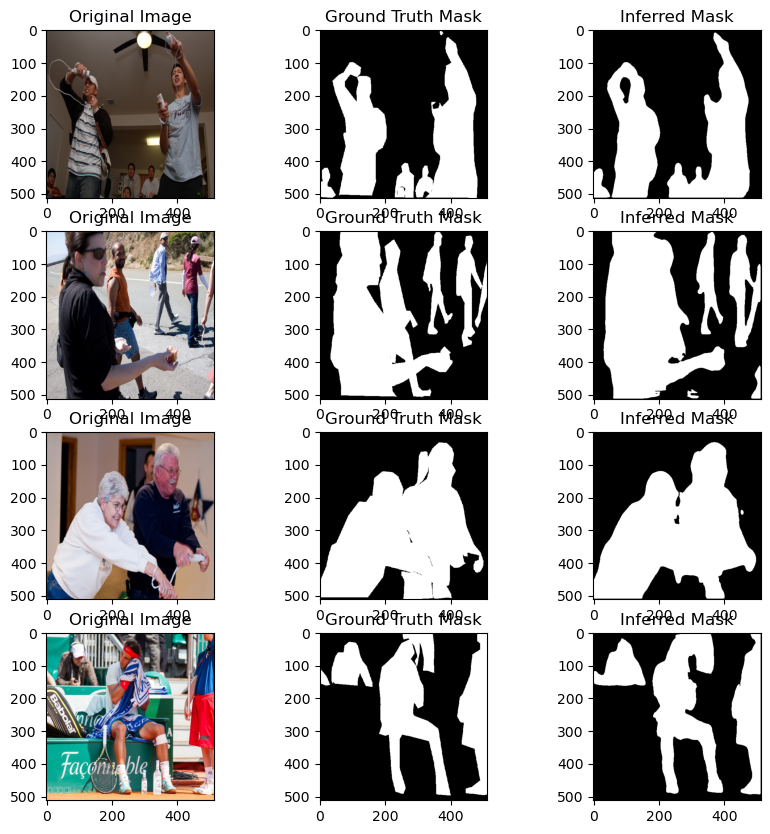

In [94]:
import torch
import torchvision.transforms.functional as F
from torchvision.utils import draw_segmentation_masks
from torchvision.io import read_image
import matplotlib.pyplot as plt


def draw_predicted_segmentations(model, iterator, transform) :

    # put model in evaluate
    model.eval()
    with torch.no_grad() : 

        # get batch
        images, masks = next(iterator)
        images = images.to(device)
        images_transformed = transform(images)

        # get output
        logits = model(images_transformed)

        # predict the logits
        probs = torch.sigmoid(logits)
        predictions = (probs > 0.5).float()

    num_images = images.shape[0]
    plt.figure(figsize=(10, 10))
    i = 1
    for idx in range(num_images) :

        # 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12
        # original image
        plt.subplot(num_images, 3, i)
        plt.imshow(images[idx].cpu().permute(1, 2, 0).detach().numpy())
        plt.title("Original Image")
        i += 1

        # ground truth
        plt.subplot(num_images, 3, i)
        plt.imshow(masks[idx].cpu().squeeze(), cmap='gray')
        plt.title("Ground Truth Mask")
        i += 1

        # prediction
        plt.subplot(num_images, 3, i)
        plt.imshow(predictions[idx].cpu().squeeze(), cmap='gray')
        plt.title("Inferred Mask")
        i += 1


    plt.show()


    
draw_predicted_segmentations(infer_model, plot_iter, val_transform)

images type = <class 'torch.Tensor'>


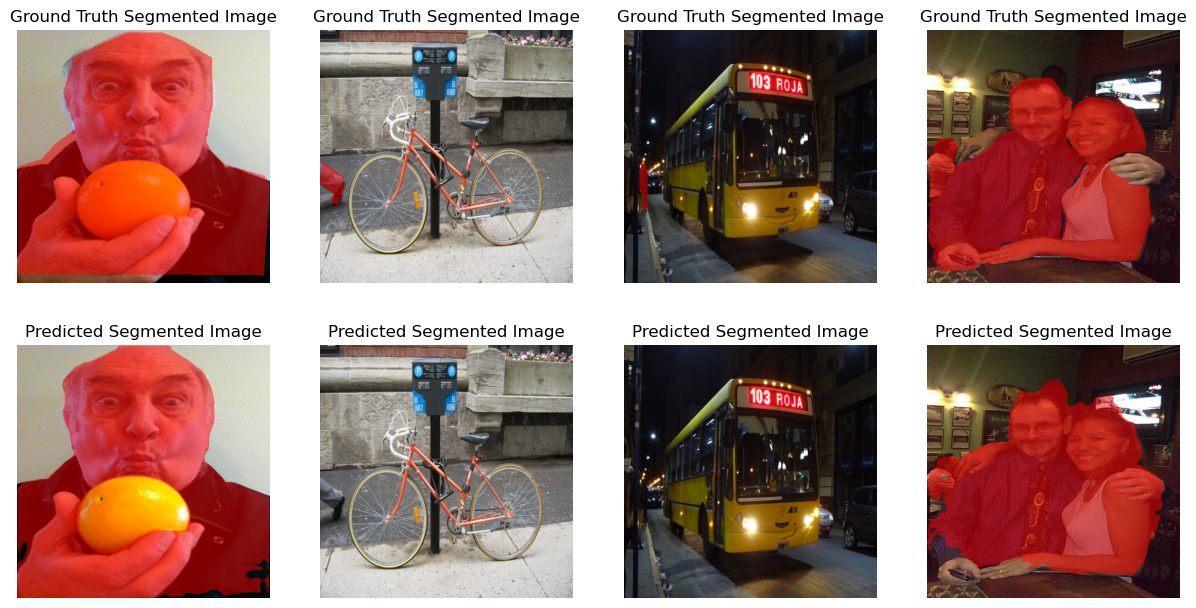

In [271]:
from torchvision.transforms import transforms

def draw_segment(model, iterator, transform) :
    # put model in evaluate
    model.eval()
    with torch.no_grad() : 

        # get batch
        images, masks = next(iterator)
        images = images.to(device)
        print(f"images type = {type(images)}")
        images_transformed = transform(images)

        # get output
        logits = model(images_transformed)

        # predict the logits
        probs = torch.sigmoid(logits)
        predictions = (probs > 0.5)

    num_images = images.shape[0]
    plt.figure(figsize=(15, 15))
    for idx in range(num_images) :
        img_uint8 = (images[idx] * 255).to(torch.uint8)
        bool_mask = predictions[idx].bool()
        ground_truth_mask = masks[idx].bool()
        segmented_image = F.to_pil_image(draw_segmentation_masks(img_uint8, bool_mask, alpha = 0.5, colors = "red"))
        ground_truth_image =  F.to_pil_image(draw_segmentation_masks(img_uint8, ground_truth_mask, alpha = 0.5, colors = "red"))

        # ground truth
        plt.subplot(1, num_images, idx + 1)
        plt.imshow(ground_truth_image)
        plt.axis('off')
        plt.title("Ground Truth Segmented Image")

        # segmented
        plt.subplot(2, num_images, (idx + 1) + 4)
        plt.imshow(segmented_image)
        plt.axis('off')
        plt.title("Predicted Segmented Image")

    
    plt.show()
    

draw_segment(infer_model, plot_iter, val_transform)

bool_mask shape = torch.Size([1, 512, 512])


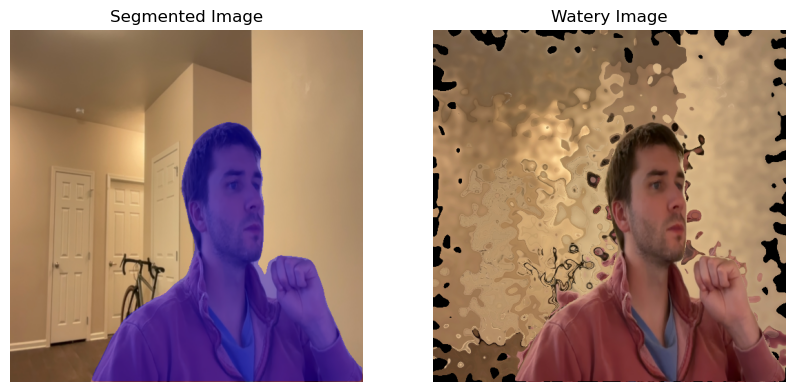

In [ ]:
import torchvision.transforms.functional as F
from PIL import Image

def draw_segment(model, uploaded_image, transform) :
    # put model in evaluate
    model.eval()
    with torch.no_grad() : 

        # get batch
        image_tensor = F.to_tensor(uploaded_image)
        image_tensor_for_display = F.resize(image_tensor, size = (512, 512), antialias = True)
        image_tensor = image_tensor.unsqueeze(0)
        image_transformed = transform(image_tensor)

        # get output
        image_transformed = image_transformed.to(device)
        logits = model(image_transformed)

        # predict the logits
        probs = torch.sigmoid(logits).squeeze(0)
        prediction = (probs > 0.5).bool()

    plt.figure(figsize=(10, 10))

    # segment image
    img_uint8 = (image_tensor_for_display * 255).to(torch.uint8)
    bool_mask = prediction.bool()
    segmented_image = F.to_pil_image(draw_segmentation_masks(img_uint8, bool_mask, alpha = 0.40, colors = "blue"))
    plt.subplot(1, 2, 1)
    plt.imshow(segmented_image)
    plt.axis('off')
    plt.title("Segmented Image")

    # apply elastic
    elastic_transformer = v2.ElasticTransform(alpha = 1000.0)
    watery_image = elastic_transformer(image_tensor_for_display)
    watery_uint8 = (watery_image * 255).to(torch.uint8)
    watery = torch.where(bool_mask.to(device), img_uint8.to(device), watery_uint8.to(device))
    watery = watery.to("cpu")
    watery_image = F.to_pil_image(watery)
    plt.subplot(1,2,2)
    plt.imshow(watery_image)
    plt.axis('off')
    plt.title("Watery Image")


    plt.show()
    

example_image = Image.open('example_image_1.jpg')
draw_segment(infer_model, example_image, val_transform)

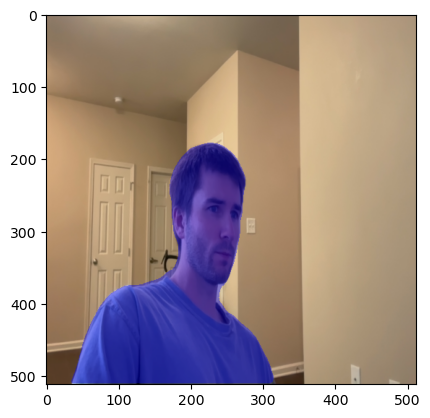

In [317]:
import torchvision.transforms.functional as F
from PIL import Image
import io
import json
import base64
import requests

#def draw_segment(model, uploaded_image_path, transform) :

url = "https://nc2xhheqaivoywho43qhnvzwqm0agtzo.lambda-url.us-east-1.on.aws/"

# image
uploaded_image = Image.open('ex1.jpg')
image_tensor_for_display = F.resize(F.to_tensor(uploaded_image), size = (512, 512), antialias = True)

# convert to base64 to send. PNG is lossless. JPEG is not.
buffered = io.BytesIO()
uploaded_image.save(buffered, format = "PNG")
uploaded_image_b64_string = base64.b64encode(buffered.getvalue()).decode('utf-8')

payload = {
        "data": uploaded_image_b64_string
    }

response = requests.post(url, json = payload)
mask_b64 = response.json().get("mask")
mask_bytes = base64.b64decode(mask_b64)
mask_image = Image.open(io.BytesIO(mask_bytes))

# segment image
img_uint8 = (image_tensor_for_display * 255).to(torch.uint8)
bool_mask = F.to_tensor(mask_image).bool()
segmented_image = F.to_pil_image(draw_segmentation_masks(img_uint8, bool_mask, alpha = 0.40, colors = "blue"))
plt.imshow(segmented_image)


    

